# Bike Sharing Demand예측 AI모델 개발

## 개요
- 시간대별 자전거 대여량 예측

## 분석 배경 
- 워싱턴 D.C 소재의 자전거 대여 스타트업인 Capital Bikeshare의 데이터를 활용
- 시간대별 자전거 대여량 예측함
- https://softeer.ai/practice?type=DA&page=0

## 평가 지표
- RMSLE : Root Mean Scaled Logarithmic Error
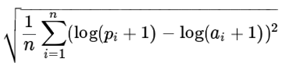

## 데이터 셋 정보


### [Data Files]
- (2011, 2012) 2년간 데이터
- train.csv: 학습용 데이터 (Features, Target) - 7,620건     
- test.csv:  예측용 데이터 (Features) - 3,266건

### [Feature]
- datetime: 자전거 대여가 일어난 년-월-일-시-분-초
- season: 계절
    – 1 = spring, 2 = summer, 3 = fall, 4 = winter
- holiday: 공휴일이면 1, 아니면 0
- workingday: 근무일이면 1, 아니면 0
- weather (날씨)
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: 온도
- atemp: 체감온도
- humidity: 습도
- windspeed: 풍속

### [Target]
- count: (시간대별) 자건거 대여량
    - count = casual(비회원의 대여량) + registered(회원의 대여량)

## (4) 분석 단계
- **[step1] 라이브러리 및 데이터 불러오기**
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기
 - (3) 데이터 확인
 - (4) 데이터 타입 변환 (필요시)
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계**
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가
 - (4) 하이퍼 파라미터 튜닝
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
 - (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)
- **[step6] 결과 파일 생성**
 - (1) 예시 파일 불러오기
 - (2) test data의 예측 결과 저장
 - (3) 제출할 csv파일 생성

## [Step1] 불러오기
### (1) 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
from sklearn.model_selection import train_test_split  #학습셋과 검증셋 분리
from sklearn.model_selection import GridSearchCV  # 하이퍼파라미터 튜닝

### (2) 데이터 불러오기

**train data**

In [4]:
#train set load
train = pd.read_csv('./data/train.csv')
train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-12-07 14:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215
1,2012-06-17 1:00,2,0,0,1,22.96,26.515,60,11.0014,21,67,88
2,2012-07-05 22:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225
3,2011-07-17 12:00,3,0,0,1,31.16,34.850,55,19.0012,177,243,420
4,2011-11-09 15:00,4,0,1,1,21.32,25.000,45,15.0013,21,130,151
...,...,...,...,...,...,...,...,...,...,...,...,...
7615,2012-11-01 12:00,4,0,1,3,15.58,19.695,62,11.0014,23,198,221
7616,2012-09-12 7:00,3,0,1,1,21.32,25.000,72,0.0000,24,533,557
7617,2011-11-19 0:00,4,0,0,1,10.66,12.880,56,12.9980,4,49,53
7618,2011-03-09 8:00,1,0,1,2,9.84,12.120,87,8.9981,11,238,249


**test data**

In [5]:
#test set load
test = pd.read_csv('./data/test.csv')
test

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2012-06-14 13:00,2,0,1,1,27.88,31.820,57,11.0014
1,2011-11-13 0:00,4,0,0,2,16.40,20.455,58,12.9980
2,2012-08-16 1:00,3,0,1,1,26.24,30.305,73,0.0000
3,2011-12-14 19:00,4,0,1,2,14.76,18.180,62,7.0015
4,2011-10-12 6:00,4,0,1,2,22.14,25.760,88,16.9979
...,...,...,...,...,...,...,...,...,...
3261,2012-01-16 5:00,1,1,0,1,4.92,8.335,54,6.0032
3262,2012-07-09 13:00,3,0,1,2,31.16,34.850,55,16.9979
3263,2012-05-01 9:00,2,0,1,2,22.14,25.760,88,12.9980
3264,2012-01-15 23:00,1,0,0,1,6.56,9.850,43,6.0032


### (3) 데이터 확인 
 - df.info()

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    7620 non-null   object 
 1   season      7620 non-null   int64  
 2   holiday     7620 non-null   int64  
 3   workingday  7620 non-null   int64  
 4   weather     7620 non-null   int64  
 5   temp        7620 non-null   float64
 6   atemp       7620 non-null   float64
 7   humidity    7620 non-null   int64  
 8   windspeed   7620 non-null   float64
 9   casual      7620 non-null   int64  
 10  registered  7620 non-null   int64  
 11  count       7620 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 714.5+ KB


- Column: 12개, 데이터 건수: 7620
- 모든 변수의 Non-Null Count 값이 7620 건으로 train data에 결측치가 없음
- **datetime**의 데이터 타입이 object(문자열)임

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    3266 non-null   object 
 1   season      3266 non-null   int64  
 2   holiday     3266 non-null   int64  
 3   workingday  3266 non-null   int64  
 4   weather     3266 non-null   int64  
 5   temp        3266 non-null   float64
 6   atemp       3266 non-null   float64
 7   humidity    3266 non-null   int64  
 8   windspeed   3266 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 229.8+ KB


- Column: 12개, 데이터 건수: 3266
- 모든 변수의 Non-Null Count 값이 3266 건으로 test data에도 결측치가 없음
- **datetime**의 데이터 타입이 object(문자열)임

### (4) 데이터 타입 변환 
- **datetime**을 수치형 데이터 타입인 **datetime64**로 변환
- 년/월/일/시/분/초 형식의 **datetime64**로 변환해야 추후 분석이 용이함
    - 예를 들면, **년,월,일,시,분,초** 값을 각각 **분리**할 수 있음

#### train data

In [8]:
#datetiem64 형식으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])  

In [9]:
#변환되었는지 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    7620 non-null   datetime64[ns]
 1   season      7620 non-null   int64         
 2   holiday     7620 non-null   int64         
 3   workingday  7620 non-null   int64         
 4   weather     7620 non-null   int64         
 5   temp        7620 non-null   float64       
 6   atemp       7620 non-null   float64       
 7   humidity    7620 non-null   int64         
 8   windspeed   7620 non-null   float64       
 9   casual      7620 non-null   int64         
 10  registered  7620 non-null   int64         
 11  count       7620 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 714.5 KB


- datetime64형 변수의 **dt 속성**을 이용, 년,월,일,시,분,초 값 분리
    - (ex: dt.year, dt.month)

In [10]:
# 년,월,일,시,분,초 값 분리
train['year']=train['datetime'].dt.year     # 1. 년도 추출 
train['month']=train['datetime'].dt.month   # 2. 월 추출 
train['day']=train['datetime'].dt.day       # 3. 일 추출 
train['hour']=train['datetime'].dt.hour     # 4. 시 추출 
train['minute']=train['datetime'].dt.minute # 5. 분 추출 
train['second']=train['datetime'].dt.second # 6. 초 추출 

In [11]:
train['dayofweek']=train['datetime'].dt.dayofweek 
#7. 요일 추출  (월요일:0, 일요일:6)

In [12]:
# 결과 확인
print(train.shape)
train.head()

(7620, 19)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,dayofweek
0,2012-12-07 14:00:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215,2012,12,7,14,0,0,4
1,2012-06-17 01:00:00,2,0,0,1,22.96,26.515,60,11.0014,21,67,88,2012,6,17,1,0,0,6
2,2012-07-05 22:00:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225,2012,7,5,22,0,0,3
3,2011-07-17 12:00:00,3,0,0,1,31.16,34.850,55,19.0012,177,243,420,2011,7,17,12,0,0,6
4,2011-11-09 15:00:00,4,0,1,1,21.32,25.000,45,15.0013,21,130,151,2011,11,9,15,0,0,2


#### test data

In [13]:
#datetiem64 형식으로 변환
test['datetime'] = pd.to_datetime(test['datetime']) 

In [14]:
#변환되었는지 확인
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    3266 non-null   datetime64[ns]
 1   season      3266 non-null   int64         
 2   holiday     3266 non-null   int64         
 3   workingday  3266 non-null   int64         
 4   weather     3266 non-null   int64         
 5   temp        3266 non-null   float64       
 6   atemp       3266 non-null   float64       
 7   humidity    3266 non-null   int64         
 8   windspeed   3266 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(5)
memory usage: 229.8 KB


In [15]:
# 년,월,일,시,분,초 값 분리
test['year']=test['datetime'].dt.year # 년도 추출 
test['month']=test['datetime'].dt.month # 월도 추출 
test['day']=test['datetime'].dt.day # 일 추출 
test['hour']=test['datetime'].dt.hour # 시 추출 
test['minute']=test['datetime'].dt.minute # 분 추출 
test['second']=test['datetime'].dt.second # 초 추출 
test['dayofweek']=test['datetime'].dt.dayofweek #요일 추출 , 월요일:0, 일요일:6

In [16]:
# 결과 확인
print(test.shape)
test.head()

(3266, 16)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,minute,second,dayofweek
0,2012-06-14 13:00:00,2,0,1,1,27.88,31.820,57,11.0014,2012,6,14,13,0,0,3
1,2011-11-13 00:00:00,4,0,0,2,16.40,20.455,58,12.9980,2011,11,13,0,0,0,6
2,2012-08-16 01:00:00,3,0,1,1,26.24,30.305,73,0.0000,2012,8,16,1,0,0,3
3,2011-12-14 19:00:00,4,0,1,2,14.76,18.180,62,7.0015,2011,12,14,19,0,0,2
4,2011-10-12 06:00:00,4,0,1,2,22.14,25.760,88,16.9979,2011,10,12,6,0,0,2


## [Step2] 탐색적 데이터 분석 (EDA)

### (1) 기술통계분석
- describe()를 이용한 통계치 확인

In [17]:
# 각 변수들의 기초 통계량을 확인합니다
train.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,dayofweek
count,7620,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.000000,7620.0,7620.0,7620.000000
mean,2011-12-25 14:06:58.110236160,2.506693,0.026903,0.681496,1.418241,20.223115,23.644734,61.859449,12.883894,36.022835,155.494094,191.516929,2011.497507,6.520735,9.972310,11.571260,0.0,0.0,3.025853
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,1.515000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000,0.0,0.0,0.000000
25%,2011-06-28 05:15:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,37.000000,42.000000,2011.000000,4.000000,5.000000,6.000000,0.0,0.0,1.000000
50%,2011-12-18 20:30:00,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,2011.000000,7.000000,10.000000,12.000000,0.0,0.0,3.000000
75%,2012-06-19 21:15:00,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,221.000000,282.000000,2012.000000,10.000000,15.000000,18.000000,0.0,0.0,5.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.000000,44.695000,100.000000,56.996900,362.000000,857.000000,970.000000,2012.000000,12.000000,19.000000,23.000000,0.0,0.0,6.000000
std,NaN,1.116208,0.161810,0.465927,0.629592,7.773995,8.460236,19.243858,8.155715,49.660086,151.428836,181.103255,0.500027,3.446890,5.477647,6.913357,0.0,0.0,2.004389


In [18]:
test.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,minute,second,dayofweek
count,3266,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.000000,3266.0,3266.0,3266.000000
mean,2011-12-31 02:51:09.810165248,2.506430,0.032456,0.679424,1.418861,20.248928,23.679233,61.949479,12.602249,2011.512247,6.523270,10.039804,11.472443,0.0,0.0,2.986222
min,2011-01-01 01:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,2011.000000,1.000000,1.000000,0.000000,0.0,0.0,0.000000
25%,2011-07-07 04:15:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,2011.000000,4.000000,5.000000,6.000000,0.0,0.0,1.000000
50%,2012-01-07 12:30:00,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,11.001400,2012.000000,7.000000,10.000000,11.000000,0.0,0.0,3.000000
75%,2012-07-02 19:15:00,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,78.000000,16.997900,2012.000000,10.000000,15.000000,17.000000,0.0,0.0,5.000000
max,2012-12-19 21:00:00,4.000000,1.000000,1.000000,3.000000,39.360000,45.455000,100.000000,56.996900,2012.000000,12.000000,19.000000,23.000000,0.0,0.0,6.000000
std,NaN,1.116268,0.177234,0.466769,0.643735,7.833651,8.509271,19.250574,8.182943,0.499927,3.439022,5.474732,6.922189,0.0,0.0,2.005076


#### [정리] 기술통계분석 결과에서
- 명목(카테고리) 변수의 경우 평균값 등이 의미가 없음! ==> 오히려 min, max를 통해 카테고리 값이 train과 test셋에 고르게 분포했는지 확인해야 함
    - season, holiday, weather, year, month, day, hour, minute, second, dayofweek
- **(중요)** weather의 경우
    - train셋: 1,2,3,4
    - test셋:  1,2,3
    - 이 경우 train셋과 test셋을 각각 one-hot 인코딩하면 **feature수가 달라지게 됨**
- 분과 초는 단일값 (0)으로 구성, 머신러닝에 도움이 되지 않음 
    - feature로 사용하지 않음, 삭제 예정
- casual과 registered를 count를 구성하는 값으로 train셋에만 있음 
    - feature로 사용하지 않음, 삭제 예정

[추가확인-weather]

In [19]:
train["weather"].value_counts()

weather
1    5015
2    2024
3     580
4       1
Name: count, dtype: int64

In [20]:
test["weather"].value_counts()

weather
1    2177
2     810
3     279
Name: count, dtype: int64

### (2) 변수별 분포 시각화 

#### 1) 변수들간 상관관계를 보여주는 pairplot

<Figure size 1500x1500 with 0 Axes>

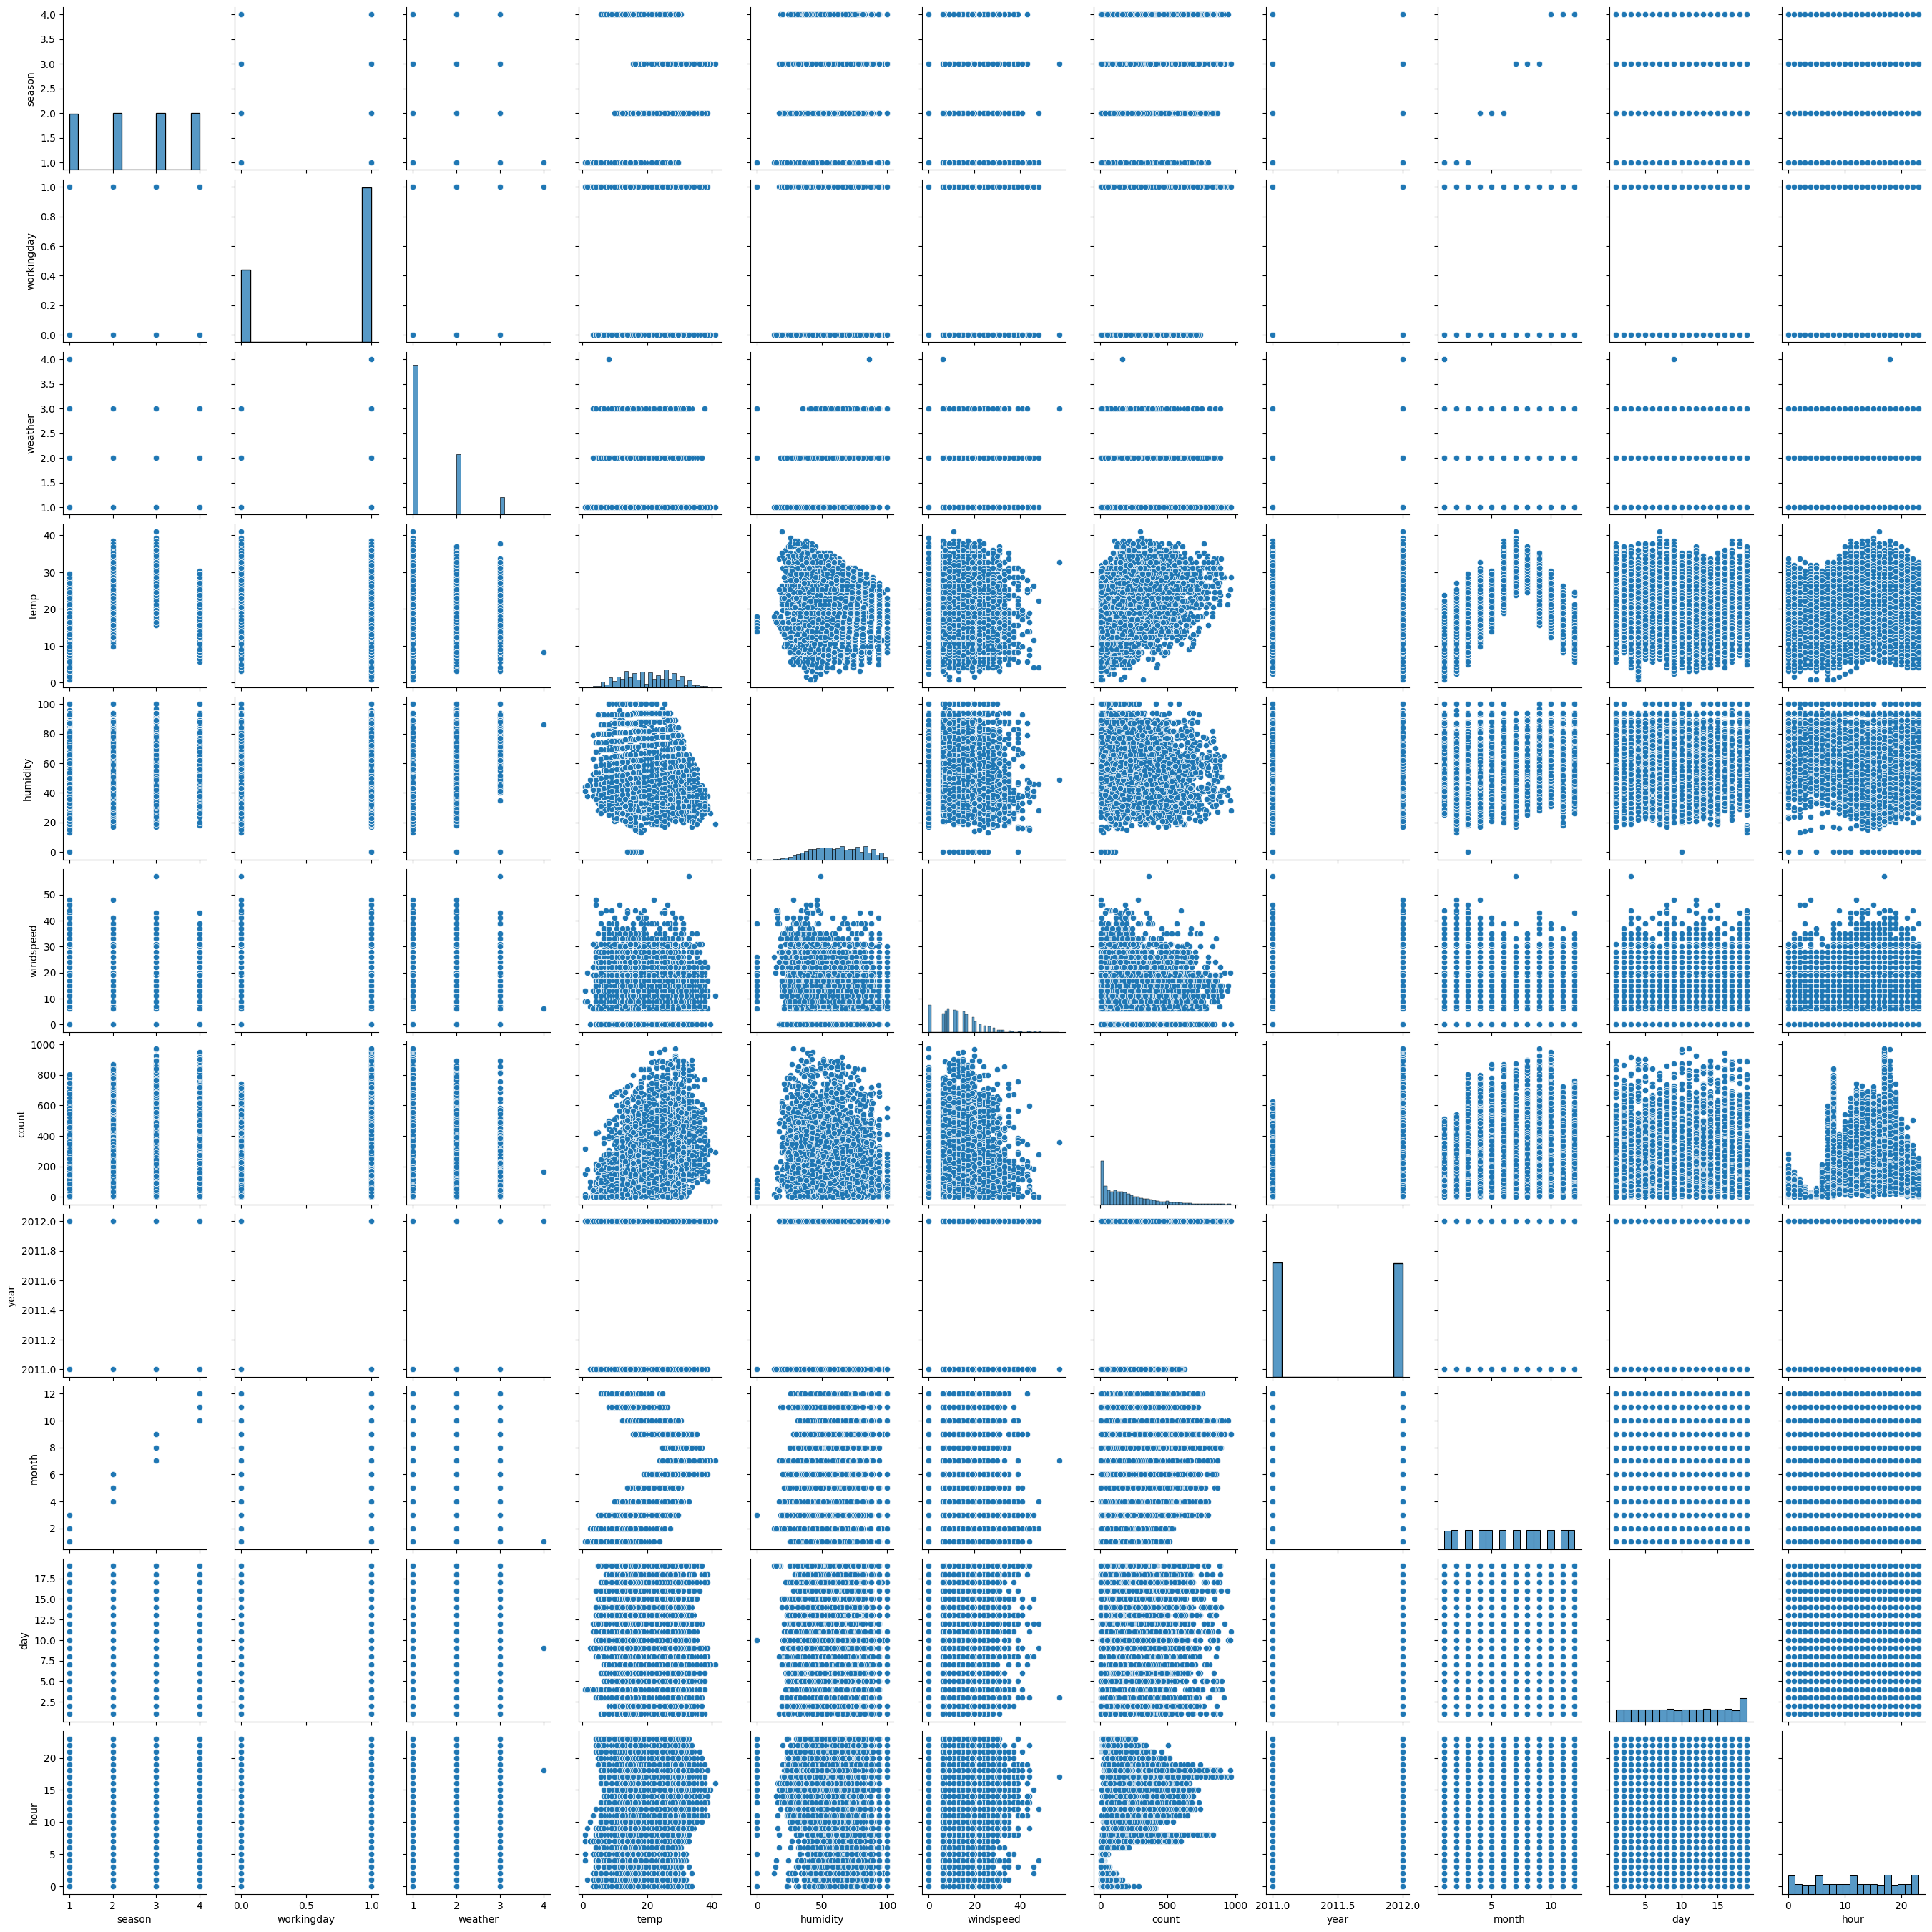

In [21]:
# pairplot -변수간 상관관계 확인

# 주요 변수만 추출하여 pairplot
train_var=train[["season","workingday","weather","temp","humidity","windspeed","count","year","month","day","hour"]]

plt.figure(figsize = (15,15))
sns.pairplot(train_var)
plt.show()

#### [정리] pairplotting을 해 보면,
- 변수의 형태에 따라서 산점도 양상이 달라짐
    - (연속형-연속형), (연속형-범주형), (범주형-범주형)
- 특히 target변수(count)와 feature와의 관계를 유심히 관찰
    - 'day'변수의 경우 유의미한 관계가 잘 보이지 않음
    - 확인을 위해 count와 년/월/일/시 변수의 산점도를 확대하여 작성해봄

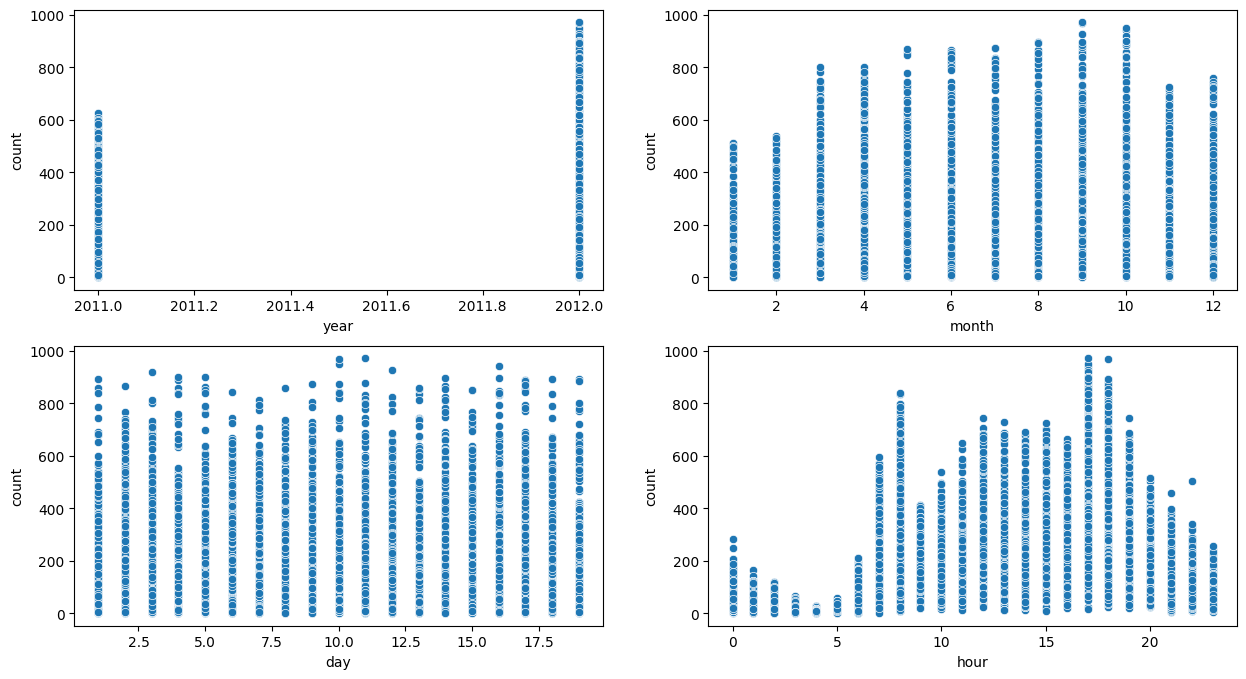

In [22]:
# count와 년/월/일/시 변수의 산점도

fig,ax=plt.subplots(nrows=2, ncols=2, figsize=(15,8))

sns.scatterplot(x=train["year"],y=train["count"],data=train, ax=ax[0][0])
sns.scatterplot(x=train["month"],y=train["count"],data=train, ax=ax[0][1])
sns.scatterplot(x=train["day"],y=train["count"],data=train, ax=ax[1][0])
sns.scatterplot(x=train["hour"],y=train["count"],data=train, ax=ax[1][1])

plt.show()

##### [결론] target에 유의미한 상관성을 보이지 않는 day 변수 제거

- pairplot의 **대각선**을 따라서는 **개별 변수 분포도**가 제시됨
    - **연속형 변수: histplot 또는 distplot(histogram )**
        - feature - temp, atemp, humidity, windspeed
        - target - count
    - **범주형 변수: countplot**
        - season, workingday, weather, year, month, hour   

#### 2) 연속형 변수의 분포를 보여주는 histplot 

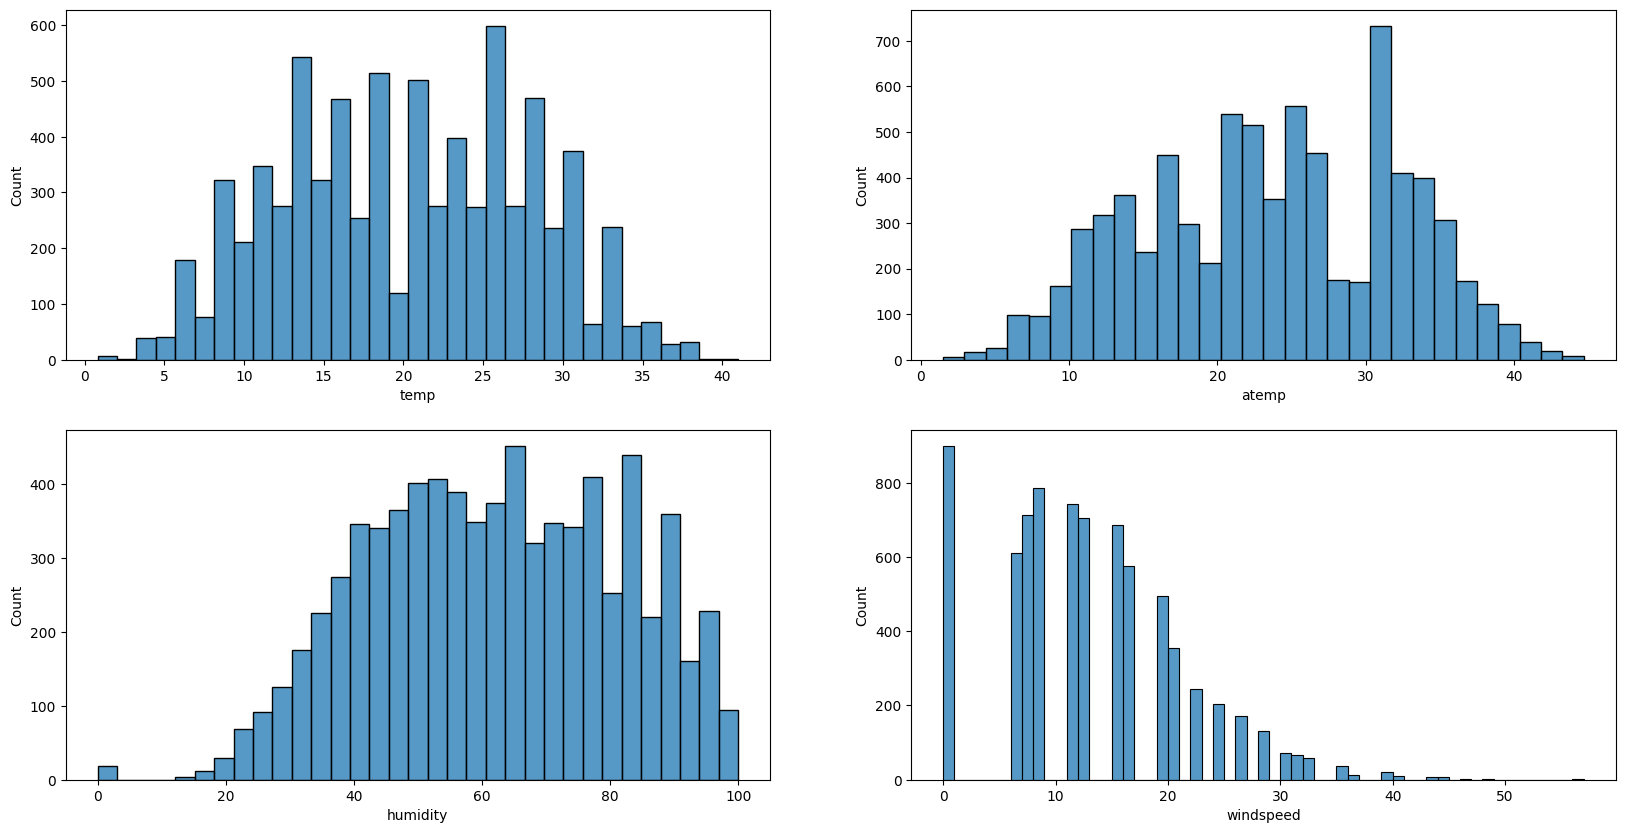

In [23]:
# feature

fig, axes = plt.subplots(2, 2, figsize=(20,10))

sns.histplot(x = train['temp'], ax=axes[0][0])
sns.histplot(x = train['atemp'],ax=axes[0][1])
sns.histplot(x = train['humidity'],ax=axes[1][0])
sns.histplot(x = train['windspeed'],ax=axes[1][1])

plt.show()

#### [Target] 
- target값의 **로그 변환** 필요성 검토

<Axes: xlabel='count', ylabel='Count'>

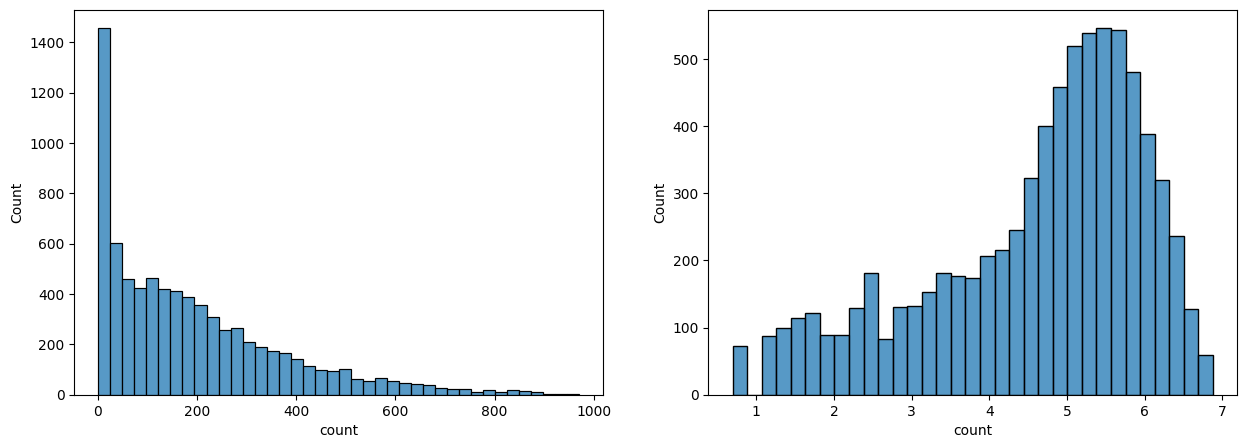

In [24]:
# target값의 원데이터와 로그변환데이터의 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x = train['count'], ax=axes[0])
sns.histplot(x = np.log1p(train['count']), ax=axes[1])

- 로그 변환 후, 분포 왜곡도가 완화됨을 알 수 있음

- [참고] np.log1p(x)함수
    - log(x+1)을 return함

### [참고] 로그 함수의 특징
- 밀집되어 있는 데이터는 퍼지게, 퍼진 데이터는 밀집되게 하여 원본의 분포왜곡을 완화

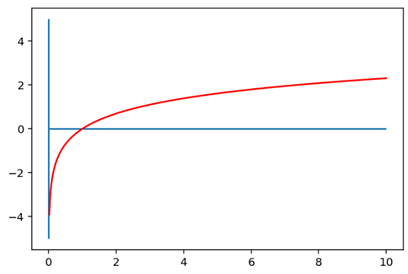

- 0<x<1 
    - 로그 변환후 (-무한대<y<0)의 범위로 분산됨 
    - 즉 제한된 범위의 x는 로그 변환 후 큰 범위로 벌어짐
- x>1
    - 로그 변환후 (0<y<특정값)의 범위로 제한됨 
    - 즉 넓은 범위의 x는 로그 변환후 범위가 제한됨

#### 3) 범주의 변수의 빈도를 보여주는 countplot

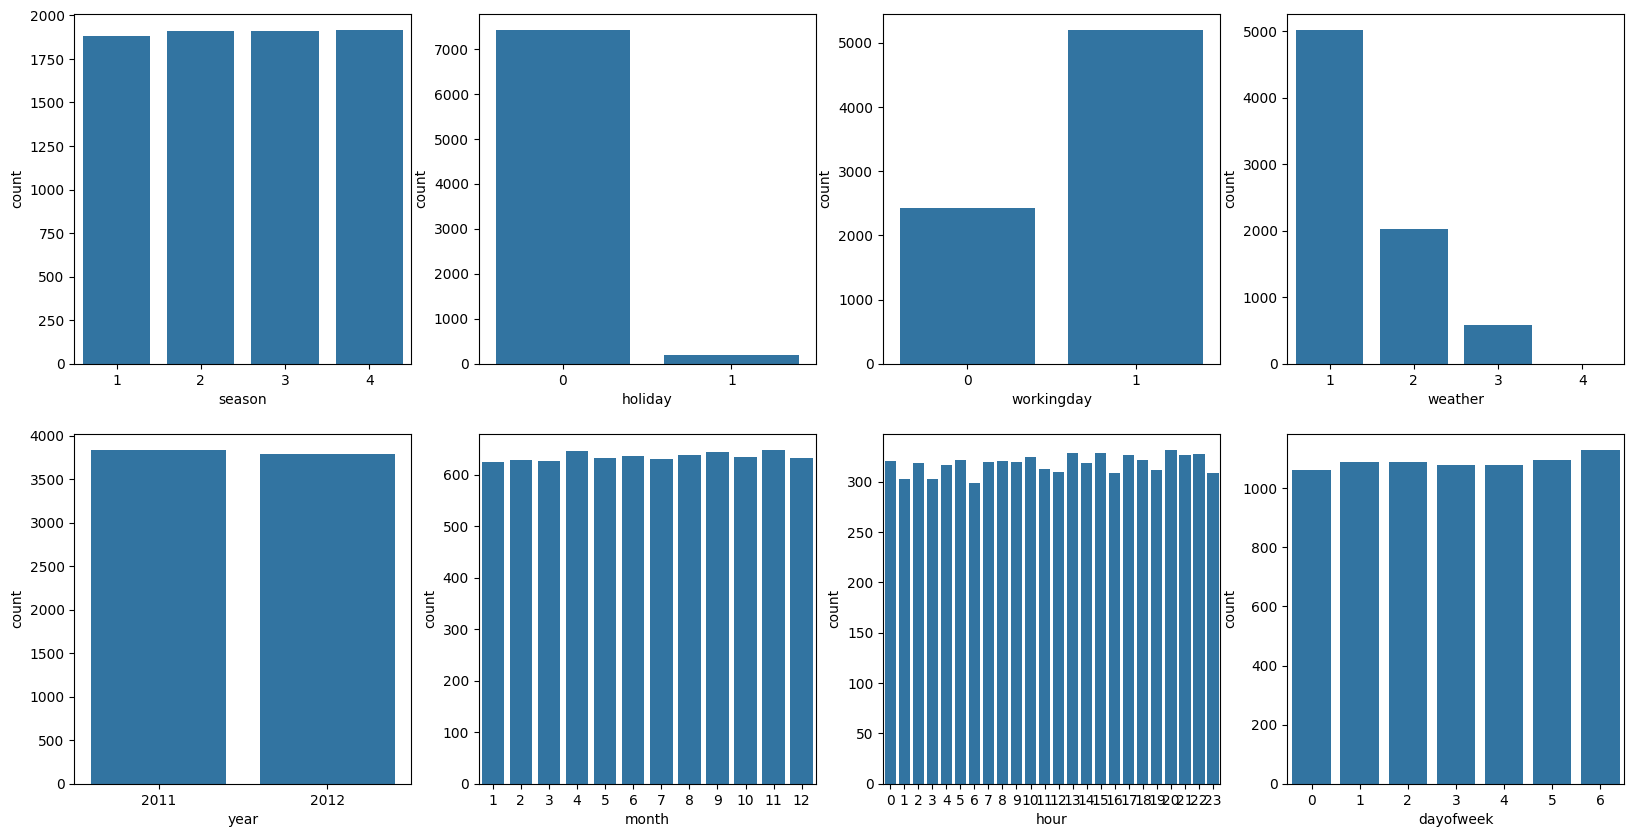

In [25]:
columns = ['season', 'holiday', 'workingday', 'weather', 'year','month', 'hour', 'dayofweek']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for col_, ax_ in zip(columns, axes.flatten()):
    sns.countplot(data=train, x=col_, ax=ax_)

plt.show()

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [26]:
# train 셋의 중복값 확인
train.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7615    False
7616    False
7617    False
7618    False
7619    False
Length: 7620, dtype: bool

In [27]:
# train 셋의 중복값의 총갯수 확인
train.duplicated().sum()

0

#### 만약 train data에 중복값이 있다면?
- df.drop_duplicates()를 이용하여 중복행을 제거

In [28]:
#중복행이 존재하는 train2를 임의로 생성
temp=train[0:2]
train2 = train.copy()
train2=pd.concat([train2, temp])
train2

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,dayofweek
0,2012-12-07 14:00:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215,2012,12,7,14,0,0,4
1,2012-06-17 01:00:00,2,0,0,1,22.96,26.515,60,11.0014,21,67,88,2012,6,17,1,0,0,6
2,2012-07-05 22:00:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225,2012,7,5,22,0,0,3
3,2011-07-17 12:00:00,3,0,0,1,31.16,34.850,55,19.0012,177,243,420,2011,7,17,12,0,0,6
4,2011-11-09 15:00:00,4,0,1,1,21.32,25.000,45,15.0013,21,130,151,2011,11,9,15,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7617,2011-11-19 00:00:00,4,0,0,1,10.66,12.880,56,12.9980,4,49,53,2011,11,19,0,0,0,5
7618,2011-03-09 08:00:00,1,0,1,2,9.84,12.120,87,8.9981,11,238,249,2011,3,9,8,0,0,2
7619,2011-03-17 08:00:00,1,0,1,1,14.76,17.425,66,8.9981,17,282,299,2011,3,17,8,0,0,3
0,2012-12-07 14:00:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215,2012,12,7,14,0,0,4


In [29]:
train2.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7617    False
7618    False
7619    False
0        True
1        True
Length: 7622, dtype: bool

In [30]:
#중복행 제거 - 앞쪽을 유지, 뒷쪽을 삭제
train2.drop_duplicates(keep='first', ignore_index=True)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,dayofweek
0,2012-12-07 14:00:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215,2012,12,7,14,0,0,4
1,2012-06-17 01:00:00,2,0,0,1,22.96,26.515,60,11.0014,21,67,88,2012,6,17,1,0,0,6
2,2012-07-05 22:00:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225,2012,7,5,22,0,0,3
3,2011-07-17 12:00:00,3,0,0,1,31.16,34.850,55,19.0012,177,243,420,2011,7,17,12,0,0,6
4,2011-11-09 15:00:00,4,0,1,1,21.32,25.000,45,15.0013,21,130,151,2011,11,9,15,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,2012-11-01 12:00:00,4,0,1,3,15.58,19.695,62,11.0014,23,198,221,2012,11,1,12,0,0,3
7616,2012-09-12 07:00:00,3,0,1,1,21.32,25.000,72,0.0000,24,533,557,2012,9,12,7,0,0,2
7617,2011-11-19 00:00:00,4,0,0,1,10.66,12.880,56,12.9980,4,49,53,2011,11,19,0,0,0,5
7618,2011-03-09 08:00:00,1,0,1,2,9.84,12.120,87,8.9981,11,238,249,2011,3,9,8,0,0,2


In [31]:
#중복행 제거 - 뒷쪽을 유지, 앞쪽을 삭제
train2.drop_duplicates(keep='last', inplace=True)
train2

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second,dayofweek
2,2012-07-05 22:00:00,3,0,1,1,33.62,40.150,59,8.9981,63,162,225,2012,7,5,22,0,0,3
3,2011-07-17 12:00:00,3,0,0,1,31.16,34.850,55,19.0012,177,243,420,2011,7,17,12,0,0,6
4,2011-11-09 15:00:00,4,0,1,1,21.32,25.000,45,15.0013,21,130,151,2011,11,9,15,0,0,2
5,2012-07-18 16:00:00,3,0,1,1,30.34,34.850,66,16.9979,34,190,224,2012,7,18,16,0,0,2
6,2012-08-16 04:00:00,3,0,1,1,25.42,29.545,73,15.0013,2,3,5,2012,8,16,4,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7617,2011-11-19 00:00:00,4,0,0,1,10.66,12.880,56,12.9980,4,49,53,2011,11,19,0,0,0,5
7618,2011-03-09 08:00:00,1,0,1,2,9.84,12.120,87,8.9981,11,238,249,2011,3,9,8,0,0,2
7619,2011-03-17 08:00:00,1,0,1,1,14.76,17.425,66,8.9981,17,282,299,2011,3,17,8,0,0,3
0,2012-12-07 14:00:00,4,0,1,2,14.76,17.425,71,11.0014,40,175,215,2012,12,7,14,0,0,4


In [32]:
train2.duplicated()

2       False
3       False
4       False
5       False
6       False
        ...  
7617    False
7618    False
7619    False
0       False
1       False
Length: 7620, dtype: bool

### (2) 불필요한 Feature 삭제

In [33]:
# train set
train.drop(['datetime', 'day', 'minute','second','casual', 'registered'], 
           axis=1, inplace=True)
train

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,dayofweek
0,4,0,1,2,14.76,17.425,71,11.0014,215,2012,12,14,4
1,2,0,0,1,22.96,26.515,60,11.0014,88,2012,6,1,6
2,3,0,1,1,33.62,40.150,59,8.9981,225,2012,7,22,3
3,3,0,0,1,31.16,34.850,55,19.0012,420,2011,7,12,6
4,4,0,1,1,21.32,25.000,45,15.0013,151,2011,11,15,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,4,0,1,3,15.58,19.695,62,11.0014,221,2012,11,12,3
7616,3,0,1,1,21.32,25.000,72,0.0000,557,2012,9,7,2
7617,4,0,0,1,10.66,12.880,56,12.9980,53,2011,11,0,5
7618,1,0,1,2,9.84,12.120,87,8.9981,249,2011,3,8,2


In [34]:
# test set
test.drop(['datetime', 'day', 'minute','second'], 
           axis=1, inplace=True)
test

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,dayofweek
0,2,0,1,1,27.88,31.820,57,11.0014,2012,6,13,3
1,4,0,0,2,16.40,20.455,58,12.9980,2011,11,0,6
2,3,0,1,1,26.24,30.305,73,0.0000,2012,8,1,3
3,4,0,1,2,14.76,18.180,62,7.0015,2011,12,19,2
4,4,0,1,2,22.14,25.760,88,16.9979,2011,10,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3261,1,1,0,1,4.92,8.335,54,6.0032,2012,1,5,0
3262,3,0,1,2,31.16,34.850,55,16.9979,2012,7,13,0
3263,2,0,1,2,22.14,25.760,88,12.9980,2012,5,9,1
3264,1,0,0,1,6.56,9.850,43,6.0032,2012,1,23,6


### (3) 결측치 처리

- df.info()를 통해 train과 test 데이터에 결측치가 없음을 이미 확인 했음
- 추가적으로 아래 방법으로도 확인 가능

In [35]:
train.isnull() 

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,dayofweek
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,False,False,False,False,False,False,False,False,False,False,False,False,False
7616,False,False,False,False,False,False,False,False,False,False,False,False,False
7617,False,False,False,False,False,False,False,False,False,False,False,False,False
7618,False,False,False,False,False,False,False,False,False,False,False,False,False


In [36]:
train.isnull().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
year          0
month         0
hour          0
dayofweek     0
dtype: int64

In [37]:
test.isnull() 

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,dayofweek
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3261,False,False,False,False,False,False,False,False,False,False,False,False
3262,False,False,False,False,False,False,False,False,False,False,False,False
3263,False,False,False,False,False,False,False,False,False,False,False,False
3264,False,False,False,False,False,False,False,False,False,False,False,False


In [38]:
test.isnull().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
year          0
month         0
hour          0
dayofweek     0
dtype: int64

#### [정리] 만약 결측값이 있다면?
- df.fillna()를 이용하여 결측값을 채움

In [39]:
# train2를 생성, 일부 field를 결측값으로 변경
train2 = train.copy()
train2.loc[0, 'temp'] = np.nan
train2.loc[1, 'atemp'] = np.nan
train2.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,dayofweek
0,4,0,1,2,NaN,17.425,71,11.0014,215,2012,12,14,4
1,2,0,0,1,22.96,NaN,60,11.0014,88,2012,6,1,6
2,3,0,1,1,33.62,40.150,59,8.9981,225,2012,7,22,3
3,3,0,0,1,31.16,34.850,55,19.0012,420,2011,7,12,6
4,4,0,1,1,21.32,25.000,45,15.0013,151,2011,11,15,2


In [40]:
# 결측값을 0으로 채우기
train3=train2.fillna(0)
train3.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,dayofweek
0,4,0,1,2,0.00,17.425,71,11.0014,215,2012,12,14,4
1,2,0,0,1,22.96,0.000,60,11.0014,88,2012,6,1,6
2,3,0,1,1,33.62,40.150,59,8.9981,225,2012,7,22,3
3,3,0,0,1,31.16,34.850,55,19.0012,420,2011,7,12,6
4,4,0,1,1,21.32,25.000,45,15.0013,151,2011,11,15,2


In [41]:
# 결측값을 해당 column 평균값으로 채우기
train3=train2.fillna(train2.mean())
train3.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,hour,dayofweek
0,4,0,1,2,20.223833,17.425000,71,11.0014,215,2012,12,14,4
1,2,0,0,1,22.960000,23.644357,60,11.0014,88,2012,6,1,6
2,3,0,1,1,33.620000,40.150000,59,8.9981,225,2012,7,22,3
3,3,0,0,1,31.160000,34.850000,55,19.0012,420,2011,7,12,6
4,4,0,1,1,21.320000,25.000000,45,15.0013,151,2011,11,15,2


### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
- target값을 기준으로 아웃라이어제거
- train셋에만 해당

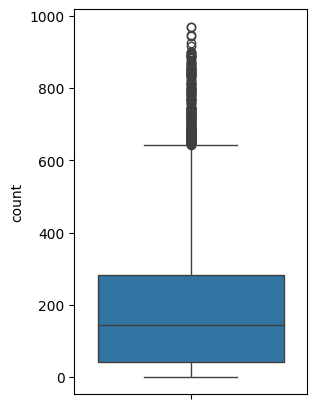

In [42]:
# boxplotting을 통해 outlier 존재여부 확인
plt.figure(figsize=(3,5))
sns.boxplot(y="count",data=train)   
plt.show()

- 아웃라이어 제거 방법
    - 1) 사분위수 범위(IQR = Q3-Q1)을 계산
    - 2) **Q1-1.5IQR**과 **Q3+1.5IQR**을 각각 max와 min으로 설정
    - 3) [min, max]를 벗어나는 데이터는 아웃라이어로 간주하여 제거

- target의 아웃라이어를 삭제하는 상기의 작업을 수행하지 않음
- 모델을 왜곡시키는 극단치라기 보다는 자연스러운 데이터로 간주

### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [43]:
# train set - features 설정
Xtrain=train.drop(['count'], axis=1)
Xtrain

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,dayofweek
0,4,0,1,2,14.76,17.425,71,11.0014,2012,12,14,4
1,2,0,0,1,22.96,26.515,60,11.0014,2012,6,1,6
2,3,0,1,1,33.62,40.150,59,8.9981,2012,7,22,3
3,3,0,0,1,31.16,34.850,55,19.0012,2011,7,12,6
4,4,0,1,1,21.32,25.000,45,15.0013,2011,11,15,2
...,...,...,...,...,...,...,...,...,...,...,...,...
7615,4,0,1,3,15.58,19.695,62,11.0014,2012,11,12,3
7616,3,0,1,1,21.32,25.000,72,0.0000,2012,9,7,2
7617,4,0,0,1,10.66,12.880,56,12.9980,2011,11,0,5
7618,1,0,1,2,9.84,12.120,87,8.9981,2011,3,8,2


In [44]:
# train set -- target 설정
ytrain=train['count']
ytrain

0       215
1        88
2       225
3       420
4       151
       ... 
7615    221
7616    557
7617     53
7618    249
7619    299
Name: count, Length: 7620, dtype: int64

In [45]:
# test set - features
Xtest=test.copy()
Xtest

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,dayofweek
0,2,0,1,1,27.88,31.820,57,11.0014,2012,6,13,3
1,4,0,0,2,16.40,20.455,58,12.9980,2011,11,0,6
2,3,0,1,1,26.24,30.305,73,0.0000,2012,8,1,3
3,4,0,1,2,14.76,18.180,62,7.0015,2011,12,19,2
4,4,0,1,2,22.14,25.760,88,16.9979,2011,10,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3261,1,1,0,1,4.92,8.335,54,6.0032,2012,1,5,0
3262,3,0,1,2,31.16,34.850,55,16.9979,2012,7,13,0
3263,2,0,1,2,22.14,25.760,88,12.9980,2012,5,9,1
3264,1,0,0,1,6.56,9.850,43,6.0032,2012,1,23,6


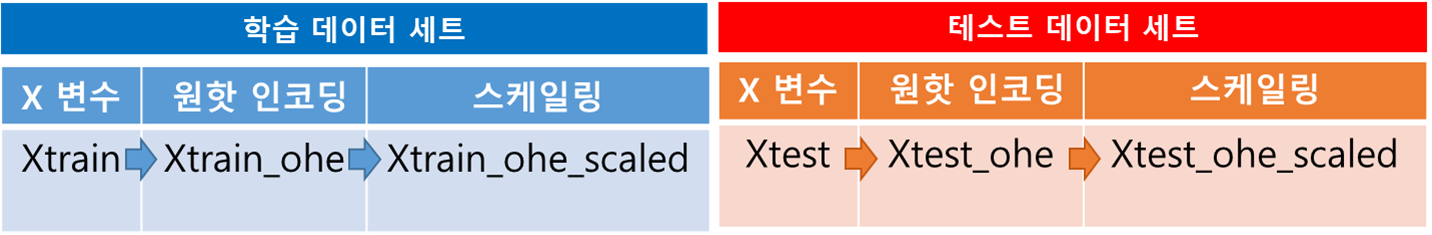

#### [중요] 만약 범주형데이터가 train셋과 test셋에 다르게 존재한다면 어떻게 될까?
- Xtrain["weather"]: 4개의 범주값
- Xtest["weather"]: 3개의 범주값

#### 이 경우 train셋과 test셋이 다르게 인코딩 될 수 있으므로 **합쳐서** 한꺼번에 인코딩!
    - train셋과 test셋 합치기: Xconcat
        - Xtrain: 0~7619(7,620개)
        - Xtest:  0~3265(3,266개)
    - Xconcat으로 총 10,886개 행의 (7,620개+3,266개) df 생성

In [46]:
Xconcat = pd.concat([Xtrain, Xtest])
Xconcat

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,hour,dayofweek
0,4,0,1,2,14.76,17.425,71,11.0014,2012,12,14,4
1,2,0,0,1,22.96,26.515,60,11.0014,2012,6,1,6
2,3,0,1,1,33.62,40.150,59,8.9981,2012,7,22,3
3,3,0,0,1,31.16,34.850,55,19.0012,2011,7,12,6
4,4,0,1,1,21.32,25.000,45,15.0013,2011,11,15,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3261,1,1,0,1,4.92,8.335,54,6.0032,2012,1,5,0
3262,3,0,1,2,31.16,34.850,55,16.9979,2012,7,13,0
3263,2,0,1,2,22.14,25.760,88,12.9980,2012,5,9,1
3264,1,0,0,1,6.56,9.850,43,6.0032,2012,1,23,6


### (6) 원핫 인코딩 **(feature-질적변수만)**
- pd.get_dummies(df, columns[해당 column명])
- 범주형 변수에 대해서 수행

In [47]:
Xconcat_ohe = pd.get_dummies(Xconcat, columns = ['year', 'month', 'hour','holiday', 'dayofweek', 'workingday','weather','season'])

In [48]:
Xconcat_ohe

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,14.76,17.425,71,11.0014,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
1,22.96,26.515,60,11.0014,False,True,False,False,False,False,...,True,False,True,False,False,False,False,True,False,False
2,33.62,40.150,59,8.9981,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,31.16,34.850,55,19.0012,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,21.32,25.000,45,15.0013,True,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,4.92,8.335,54,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
3262,31.16,34.850,55,16.9979,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
3263,22.14,25.760,88,12.9980,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3264,6.56,9.850,43,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False


In [49]:
print(Xtrain.shape)
print(Xtrain.shape[0])   
# Xtrain.shape[0] - 행의수, Xtrain.shape[1] - 열의 수

(7620, 12)
7620


In [50]:
Xtrain_ohe=Xconcat_ohe[:Xtrain.shape[0]]
Xtrain_ohe

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,14.76,17.425,71,11.0014,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
1,22.96,26.515,60,11.0014,False,True,False,False,False,False,...,True,False,True,False,False,False,False,True,False,False
2,33.62,40.150,59,8.9981,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,31.16,34.850,55,19.0012,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,21.32,25.000,45,15.0013,True,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,15.58,19.695,62,11.0014,False,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7616,21.32,25.000,72,0.0000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
7617,10.66,12.880,56,12.9980,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
7618,9.84,12.120,87,8.9981,True,False,False,False,True,False,...,False,True,False,True,False,False,True,False,False,False


In [51]:
Xtest_ohe=Xconcat_ohe[Xtrain.shape[0]:]
Xtest_ohe

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,27.88,31.820,57,11.0014,False,True,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
1,16.40,20.455,58,12.9980,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
2,26.24,30.305,73,0.0000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,14.76,18.180,62,7.0015,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,22.14,25.760,88,16.9979,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,4.92,8.335,54,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
3262,31.16,34.850,55,16.9979,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
3263,22.14,25.760,88,12.9980,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3264,6.56,9.850,43,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False


- 원핫 인코딩 이후 feature 증가

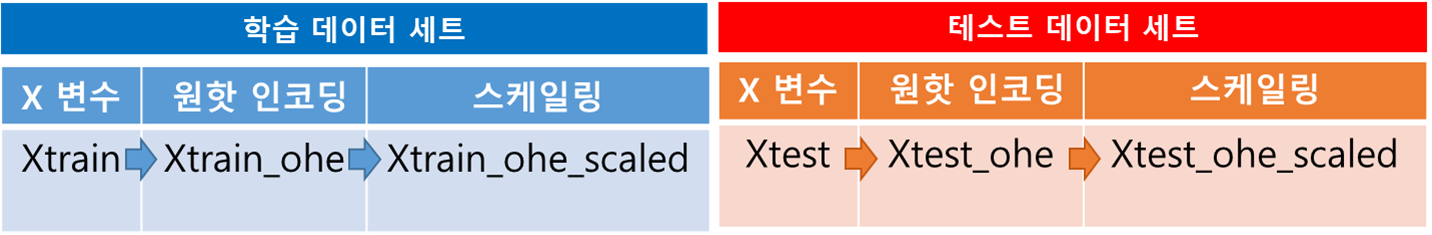

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

In [52]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#object 선언
standard_scaler = StandardScaler()
minmax_scaler= MinMaxScaler()

In [53]:
Xtrain_ohe_scaled=Xtrain_ohe.copy()
Xtrain_ohe_scaled

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,14.76,17.425,71,11.0014,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
1,22.96,26.515,60,11.0014,False,True,False,False,False,False,...,True,False,True,False,False,False,False,True,False,False
2,33.62,40.150,59,8.9981,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,31.16,34.850,55,19.0012,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,21.32,25.000,45,15.0013,True,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,15.58,19.695,62,11.0014,False,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7616,21.32,25.000,72,0.0000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
7617,10.66,12.880,56,12.9980,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
7618,9.84,12.120,87,8.9981,True,False,False,False,True,False,...,False,True,False,True,False,False,True,False,False,False


In [54]:
Xtrain_ohe_scaled[['temp','atemp','humidity']]=\
standard_scaler.fit_transform(Xtrain_ohe[['temp','atemp','humidity']])

Xtrain_ohe_scaled[['windspeed']]=\
minmax_scaler.fit_transform(Xtrain_ohe[['windspeed']])

Xtrain_ohe_scaled  #스케일링 결과 확인

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,-0.702788,-0.735221,0.475017,0.193018,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
1,0.352079,0.339288,-0.096632,0.193018,False,True,False,False,False,False,...,True,False,True,False,False,False,False,True,False,False
2,1.723408,1.951051,-0.148600,0.157870,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,1.406947,1.324550,-0.356472,0.333373,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,0.141106,0.160203,-0.876153,0.263195,True,False,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,-0.597302,-0.466889,0.007304,0.193018,False,True,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7616,0.141106,0.160203,0.526985,0.000000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
7617,-1.230222,-1.272475,-0.304504,0.228047,True,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
7618,-1.335709,-1.362313,1.306505,0.157870,True,False,False,False,True,False,...,False,True,False,True,False,False,True,False,False,False


In [55]:
Xtest_ohe_scaled=Xtest_ohe.copy()
Xtest_ohe_scaled

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,27.88,31.820,57,11.0014,False,True,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
1,16.40,20.455,58,12.9980,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
2,26.24,30.305,73,0.0000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,14.76,18.180,62,7.0015,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,22.14,25.760,88,16.9979,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,4.92,8.335,54,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
3262,31.16,34.850,55,16.9979,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
3263,22.14,25.760,88,12.9980,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3264,6.56,9.850,43,6.0032,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False


In [56]:
Xtest_ohe_scaled[['temp','atemp','humidity']]=\
standard_scaler.transform(Xtest_ohe[['temp','atemp','humidity']])

Xtest_ohe_scaled[['windspeed']]=\
minmax_scaler.transform(Xtest_ohe[['windspeed']])

Xtest_ohe_scaled  #스케일링 결과 확인

,temp,atemp,humidity,windspeed,year_2011,year_2012,month_1,month_2,month_3,month_4,...,workingday_0,workingday_1,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,0.985000,0.966380,-0.252536,0.193018,False,True,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
1,-0.491815,-0.377051,-0.200568,0.228047,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True
2,0.774027,0.787295,0.578953,0.000000,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,True,False
3,-0.702788,-0.645974,0.007304,0.122840,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,0.246593,0.250041,1.358473,0.298225,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,-1.968630,-1.809729,-0.408440,0.105325,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False
3262,1.406947,1.324550,-0.356472,0.298225,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
3263,0.246593,0.250041,1.358473,0.228047,False,True,False,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3264,-1.757656,-1.630645,-0.980089,0.105325,False,True,True,False,False,False,...,True,False,True,False,False,False,True,False,False,False


In [57]:
Xtest_ohe_scaled.min()

temp        -2.496064
atemp       -2.705153
humidity    -3.214714
windspeed         0.0
year_2011       False
               ...   
weather_4       False
season_1        False
season_2        False
season_3        False
season_4        False
Length: 61, dtype: object

In [58]:
Xtest_ohe_scaled.max()

temp         2.461815
atemp        2.578143
humidity      1.98209
windspeed         1.0
year_2011        True
               ...   
weather_4       False
season_1         True
season_2         True
season_3         True
season_4         True
Length: 61, dtype: object

##### target 로그 변환
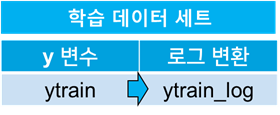

In [59]:
ytrain_log = np.log1p(ytrain)

In [60]:
# 로그 변환 후 scale down됨 -ytrain_log의 최대값 확인
ytrain_log.max()

6.878326468291325

## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
    - 선형 모델 - LinearRegression 
    - 트리기반 회귀모델 - DecisionTreeRegressor
    - 트리기반 앙상블 모델 (배깅 기법) - RandomForestRegressor, ExtraTreesRegressor
    - 트리기반 앙상블 모델 (부스팅 기법) - XGBRegressor, LGBMRegressor

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 0

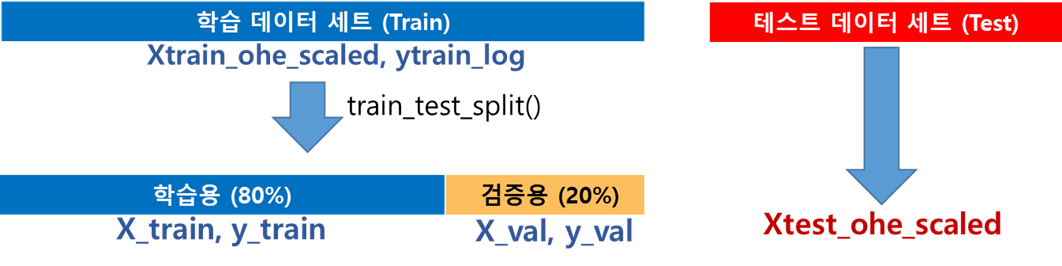

### (1) 훈련 및 검증 데이터 분할

In [61]:
# 데이터 분할: test_size=0.2, random_state=0

X_train, X_val, y_train, y_val = train_test_split(Xtrain_ohe_scaled, ytrain_log, test_size=0.2, random_state=0)

### (2) 평가지표 확인
- 평가지표가 RMSLE이므로 해당 함수를 작성해야 함

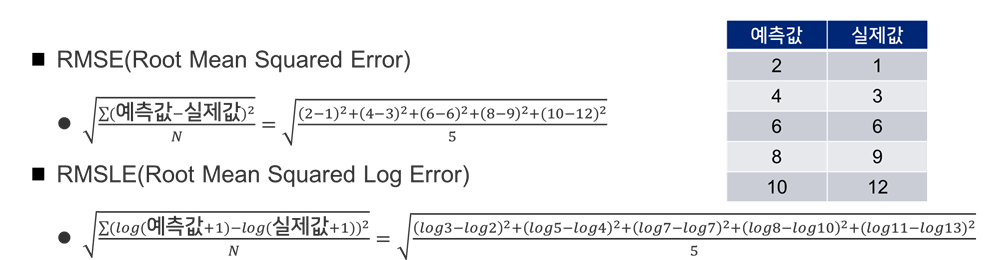

In [62]:
#실제값과 예측값의 log(x+1)값을 입력값으로 root_mean_scared_error를 구하는 함수 작성

def rmsle(log1p_actual, log1p_pred):    
    squared_error = (log1p_actual-log1p_pred)**2       
    return np.sqrt(np.mean(squared_error))         

### (3) 알고리즘별 학습, 예측, 평가 

In [63]:
# for문을 이용하여 작성
# 1) Linear Regression ~ 6) LGBM Regressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_jobs=-1),
    'Extra Trees Regressor': ExtraTreesRegressor(n_jobs=-1),
    'XGB Regressor' : XGBRegressor(verbose=-1,n_jobs=-1),
    'LGBM Regressor' : LGBMRegressor(verbose=-1,n_jobs=-1)
}

# 초기화: selected_estimator, pre_rmsle
selected_estimator = None
min_rmsle = float('inf')

# 모델 학습 및 평가
for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_val)
    rmsle_ = rmsle(y_val, pred)
    print(f'[{name} 모델의 rmsle ]: {round(rmsle_, 3)}')

    if rmsle_ < min_rmsle:
        selected_estimator = estimator
        min_rmsle = rmsle_
        print(f'selected estimator: {name}')
    print('')

[Linear Regression 모델의 rmsle ]: 0.571
selected estimator: Linear Regression

[Decision Tree Regression 모델의 rmsle ]: 0.486
selected estimator: Decision Tree Regression

[Random Forest 모델의 rmsle ]: 0.344
selected estimator: Random Forest

[Extra Trees Regressor 모델의 rmsle ]: 0.341
selected estimator: Extra Trees Regressor

[XGB Regressor 모델의 rmsle ]: 0.334
selected estimator: XGB Regressor

[LGBM Regressor 모델의 rmsle ]: 0.311
selected estimator: LGBM Regressor



**[정리] 가장 성능이 좋은 모델을 최종 선정** 

### (4) 하이퍼 파라미터 튜닝

[사용자 정의 함수로 scoring 하는 방법]
- bike예제의 rmsle처럼 사용자 정의 함수를 사용할 경우 다음과 같이 make_scorer()함수를 활용한다.
    - scoring=**make_scorer(사용자정의 함수명, greater_is_better=True(default))**
        - 회귀모델의 error지표라면 **greater_is_better=False**

    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer

- 튜닝전에, default parameter일때의 성능을 Cross Validation 기반 재검증

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters ={}

# 2) GridSearchCV 설정: 
grid_reg = GridSearchCV(selected_estimator, 
                        parameters,
                        cv=5,
                        scoring=make_scorer(rmsle))

# 3) GridSearchCV estimator로 학습: 
grid_reg.fit(Xtrain_ohe_scaled, ytrain_log)

# 4) Score확인
print('교차 검증 score: ', grid_reg.best_score_)

최적 하이퍼 파라미터 score:  0.32419147940007237


- 실제 하이퍼파라미터 튜닝 시작!

In [65]:
#1) 파라미터 설정
parameters ={'n_estimators' : [100,500] }
cv_=5

In [66]:
# 2) GridSearchCV 설정: 사용자정의 함수로 scoring 
grid_reg = GridSearchCV(selected_estimator, 
                        parameters, 
                        scoring=make_scorer(rmsle, greater_is_better=False),
                        cv=cv_) 

In [67]:
# 3) GridSearchCV estimator로 학습: 
grid_reg.fit(Xtrain_ohe_scaled, ytrain_log)

GridSearchCV(cv=5, estimator=LGBMRegressor(n_jobs=-1, verbose=-1),
             param_grid={'n_estimators': [100, 500]},
             scoring=make_scorer(rmsle, greater_is_better=False))

In [68]:
# 4) GridSearchCV 결과 확인
print('최적 하이퍼 파라미터 : ', grid_reg.best_params_)

최적 하이퍼 파라미터 :  {'n_estimators': 500}


In [69]:
# 5) GridSearchCV score 확인
print('최적 하이퍼 파라미터 score: ', -1*grid_reg.best_score_)

최적 하이퍼 파라미터 score:  0.3095461207887785


- 단 greater_is_better=False 일 경우, score는 negative로 표시됨
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer
    - make_scorer(greater_is_better=False)
        - Whether score_func is a score function (default), meaning high is good, or a loss function, meaning low is good. In the latter case, **the scorer object will sign-flip the outcome of the score_func**.

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성 
- 선정된 최고 성능의 모델로 test data 예측

In [70]:
#pred_test = lgb_reg.predict(Xtest_ohe_scaled)
pred_test = grid_reg.best_estimator_.predict(Xtest_ohe_scaled)

In [71]:
pred_test

array([5.69843223, 4.48050356, 3.39628866, ..., 5.60495679, 3.79745168,
       5.78424491])

### (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)

In [72]:
pred_test =np.expm1(pred_test)
pred_test

array([297.39921237,  87.27911524,  28.85309921, ..., 270.77018333,
        43.58741657, 324.13643931])

### (3) 실제값과 예측값의 분포 비교

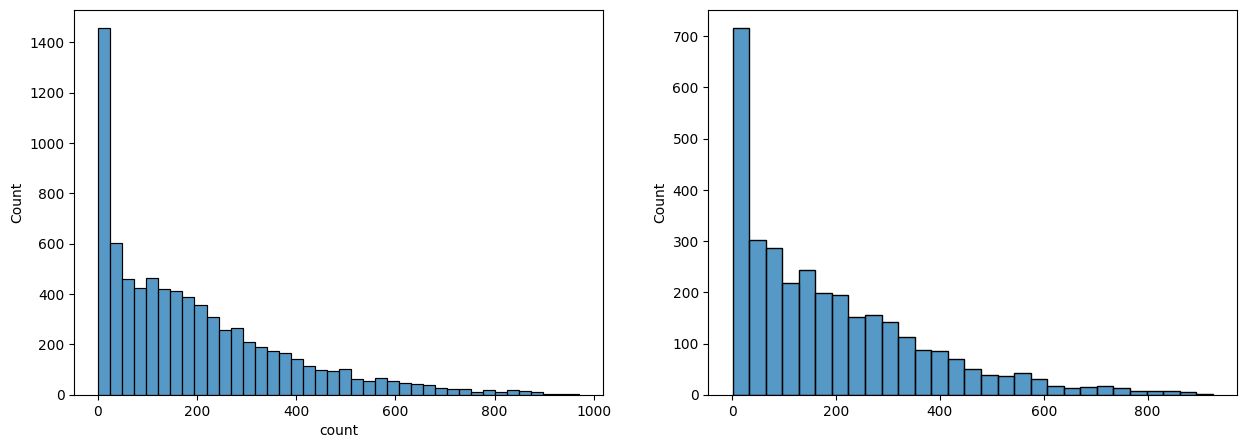

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x=ytrain, ax=axes[0]) # 실제값 
sns.histplot(x=pred_test, ax=axes[1])  # 예측값
plt.show()

- target의 실제값과 예측값의 분포가 유사함을 확인

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [74]:
#예시 파일 불러오기
submission = pd.read_csv('./data/sampleSubmission.csv')
submission.head(5)

,datetime,count
0,2012-06-14 13:00,0
1,2011-11-13 0:00,0
2,2012-08-16 1:00,0
3,2011-12-14 19:00,0
4,2011-10-12 6:00,0


### (2) 예측 결과 저장

In [75]:
#test data의 예측 결과 저장하기
submission['count'] = np.round(pred_test)
submission.head(5)

,datetime,count
0,2012-06-14 13:00,297.0
1,2011-11-13 0:00,87.0
2,2012-08-16 1:00,29.0
3,2011-12-14 19:00,264.0
4,2011-10-12 6:00,85.0


### (3) 제출할 csv파일 생성

In [76]:
#제출 파일 생성하기
submission.to_csv('./data/MySubmission.csv', index=False)

**수고하셨습니다** 

[현재 모델에서 feature_importance를 확인]

In [77]:
# 튜닝전 모델
pd.DataFrame(data=selected_estimator.feature_importances_, 
             index=selected_estimator.feature_name_,
             columns=['중요도']).sort_values(by=['중요도'], ascending=False)

,중요도
workingday_0,339
humidity,270
temp,228
atemp,123
windspeed,110
...,...
year_2012,1
workingday_1,1
weather_4,0
month_6,0


In [78]:
# 튜닝후 모델
pd.DataFrame(data=grid_reg.best_estimator_.feature_importances_, 
             index= grid_reg.best_estimator_.feature_name_ ,
             columns=['중요도']).sort_values(by=['중요도'], ascending=False)

,중요도
humidity,2666
temp,1842
windspeed,1797
atemp,1056
workingday_0,747
...,...
hour_12,41
workingday_1,0
holiday_1,0
weather_4,0


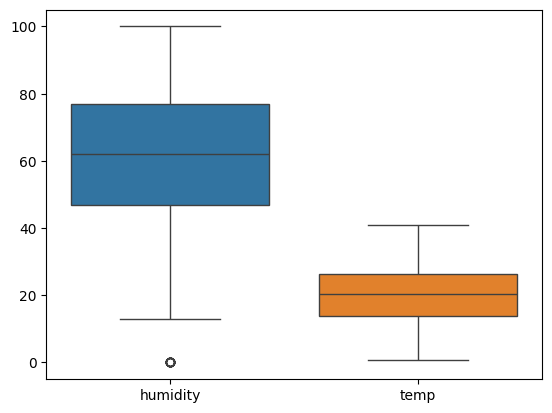

In [79]:
sns.boxplot(data=Xtrain[["humidity","temp"]])
plt.show()

In [80]:
pd.set_option('display.max_rows', 100)  # 100개까지 다 보겠다
print(Xtrain['humidity'].value_counts())  #0인 데이터가 18개

humidity
88     258
83     231
94     227
87     192
77     182
70     181
65     180
66     178
46     176
49     159
52     159
93     158
61     156
69     152
55     152
82     147
62     140
50     136
43     136
53     135
56     135
74     133
41     132
73     123
40     123
59     120
78     119
60     118
81     116
54     113
58     111
76     109
44     107
51     107
37     103
89     102
57     102
72     101
47     101
45      97
79      94
64      93
100     93
42      91
68      89
38      88
48      88
75      86
39      83
36      83
35      80
67      79
63      78
33      71
71      65
34      63
84      61
32      53
31      51
29      46
80      42
30      40
28      39
27      38
23      30
26      30
24      29
86      24
25      24
0       18
19      12
21      11
22      10
20       7
17       4
85       4
18       4
16       4
15       2
92       1
14       1
97       1
91       1
96       1
13       1
Name: count, dtype: int64


- Xtrain['humidity']==0 인 데이터를 제외하고 (아웃라이어 제거) 다시 분석하고 싶다면?